# Data Import and Load 

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("ab_data.csv")
df.head()

,user_id,timestamp,group,landing_page,converted
0,851104,2017-01-21 22:11:48.556739,control,old_page,0
1,804228,2017-01-12 08:01:45.159739,control,old_page,0
2,661590,2017-01-11 16:55:06.154213,treatment,new_page,0
3,853541,2017-01-08 18:28:03.143765,treatment,new_page,0
4,864975,2017-01-21 01:52:26.210827,control,old_page,1


# Data Understanding 

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 294478 entries, 0 to 294477
Data columns (total 5 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   user_id       294478 non-null  int64 
 1   timestamp     294478 non-null  object
 2   group         294478 non-null  object
 3   landing_page  294478 non-null  object
 4   converted     294478 non-null  int64 
dtypes: int64(2), object(3)
memory usage: 11.2+ MB


In [4]:
df['group'].value_counts()

group
treatment    147276
control      147202
Name: count, dtype: int64

In [5]:
df['landing_page'].value_counts()

landing_page
old_page    147239
new_page    147239
Name: count, dtype: int64

# Data Cleaning 

In [6]:
df = df[((df['group'] == 'control') & (df['landing_page'] == 'old_page')) |
        ((df['group'] == 'treatment') & (df['landing_page'] == 'new_page'))]

# Conversion Rate 

In [7]:
conversion_rates = df.groupby('group')['converted'].mean()
conversion_rates

group
control      0.120386
treatment    0.118807
Name: converted, dtype: float64

# Sample Size Check

In [8]:
df['group'].value_counts()

group
treatment    145311
control      145274
Name: count, dtype: int64

# Hypothesis Testing 

In [9]:
from statsmodels.stats.proportion import proportions_ztest

control = df[df['group'] == 'control']['converted']
treatment = df[df['group'] == 'treatment']['converted']

success = [control.sum(), treatment.sum()]
nobs = [control.count(), treatment.count()]

z_stat, p_value = proportions_ztest(success, nobs)

print("Z-stat:", z_stat)
print("P-value:", p_value)


Z-stat: 1.3116075339133115
P-value: 0.18965258971881804


# Confidence Interval Visualization 

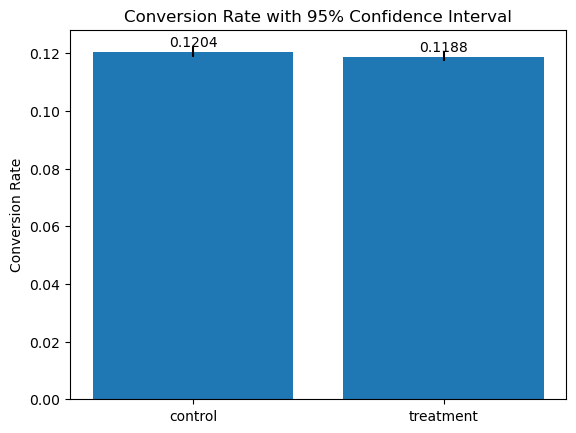

In [10]:
rates = conversion_rates.values
groups = conversion_rates.index

nobs = np.array([control.count(), treatment.count()])

std_error = np.sqrt((rates * (1 - rates)) / nobs)
ci = 1.96 * std_error

plt.figure()
plt.bar(groups, rates, yerr=ci)

for i, v in enumerate(rates):
    plt.text(i, v + 0.002, f"{v:.4f}", ha='center')

plt.title("Conversion Rate with 95% Confidence Interval")
plt.ylabel("Conversion Rate")
plt.show()

# Effect Size

In [11]:
p1 = conversion_rates['control']
p2 = conversion_rates['treatment']

cohen_h = 2 * (np.arcsin(np.sqrt(p2)) - np.arcsin(np.sqrt(p1)))
print("Cohen's h:", cohen_h)

Cohen's h: -0.00486630520161202


In [12]:
from statsmodels.stats.power import NormalIndPower
from statsmodels.stats.proportion import proportion_effectsize

effect_size = proportion_effectsize(p1, p2)

analysis = NormalIndPower()
power = analysis.power(effect_size, nobs1=control.count(), ratio=1, alpha=0.05)

print("Power:", power)

Power: 0.25888711387491165
